# COSC502 Final Project
---

In [1]:
# ============================================================
# GLOBAL IMPORTS
# Install any missing packages before the first run:
#   pip install nltk scikit-learn pandas numpy matplotlib seaborn
#               wordcloud gensim tensorflow streamlit flask
# ============================================================
%pip install wordcloud
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import zipfile
import io

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity

from wordcloud import WordCloud
from collections import Counter

# Download required NLTK data
for resource in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

print('All imports successful.')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All imports successful.


---
# QUESTION 1 — Sentiment Analysis
---

## Q1-a  Load CSV and split 70 / 30

In [2]:
# ----------------------------------------------------------------
# Q1-a: Read the CSV into a pandas DataFrame.
# The dataset has two columns:
#   'review'    – raw text of the movie review
#   'sentiment' – label: 1 = positive, 0 = negative
# ----------------------------------------------------------------
df_imdb = pd.read_csv('movie_data.csv')          # adjust path if needed

print('Shape:', df_imdb.shape)
print(df_imdb['sentiment'].value_counts())
df_imdb.head(3)

Shape: (50000, 2)
sentiment
1    25000
0    25000
Name: count, dtype: int64


,review,sentiment
0,I went and saw this movie last night after bei...,1
1,Actor turned director Bill Paxton follows up h...,1
2,As a recreational golfer with some knowledge o...,1


In [3]:
# ----------------------------------------------------------------
# Stratified split keeps the 50/50 class balance in both subsets.
# random_state=42 makes results reproducible.
# ----------------------------------------------------------------
X = df_imdb['review']
y = df_imdb['sentiment']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train_raw):,}')
print(f'Test samples     : {len(X_test_raw):,}')

Training samples : 35,000
Test samples     : 15,000


## Q1-b  Text Pre-processing

In [4]:
# ----------------------------------------------------------------
# Pre-processing pipeline:
#   1. Lowercase all characters
#   2. Remove HTML tags (IMDb reviews contain <br /> etc.)
#   3. Remove numbers
#   4. Remove punctuation
#   5. Tokenise (split into individual words)
#   6. Remove stop words (common words like 'the', 'is', 'a')
#   7. Lemmatize (reduce words to their base form, e.g. 'running' → 'run')
# ----------------------------------------------------------------
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text: str) -> str:
    """Full text cleaning pipeline.  Returns a single clean string."""
    # Step 1 – lowercase
    text = text.lower()
    # Step 2 – strip HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Step 3 – remove digits
    text = re.sub(r'\d+', '', text)
    # Step 4 – remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Step 5 – tokenise
    tokens = word_tokenize(text)
    # Steps 6 & 7 – remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

# Apply to both splits (this may take a minute on 50 k reviews)
print('Pre-processing training set ...')
X_train_clean = X_train_raw.apply(preprocess)
print('Pre-processing test set ...')
X_test_clean  = X_test_raw.apply(preprocess)

# Quick sanity check
print('\nOriginal:', X_train_raw.iloc[0][:120])
print('Cleaned :', X_train_clean.iloc[0][:120])

Pre-processing training set ...


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aaron\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aaron\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aaron\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Pre-processing test set ...

Original: At the time I recall being quite startled and amused by this movie. I referred to it as the most important movie I'd see
Cleaned : time recall quite startled amused movie referred important movie id seen ten year found bumping people said similar thin


## Q1-c  TF-IDF Feature Representations

In [5]:
# ----------------------------------------------------------------
# TF-IDF (Term Frequency – Inverse Document Frequency):
#   - TF  : how often a word appears in ONE document
#   - IDF : penalises words that appear in MANY documents (less informative)
#   - Result: high-scoring terms are frequent in a doc but rare overall
#
# ngram_range controls the vocabulary:
#   (1,1) → only single words (unigrams)
#   (1,2) → single words AND consecutive word pairs (bigrams)
#
# max_features limits vocabulary size to speed up computation.
# ----------------------------------------------------------------

# Representation 1 – unigrams only
tfidf_uni = TfidfVectorizer(ngram_range=(1, 1), max_features=10_000)
X_train_uni = tfidf_uni.fit_transform(X_train_clean)  # fit on TRAIN only
X_test_uni  = tfidf_uni.transform(X_test_clean)       # transform test (no re-fit!)

# Representation 2 – unigrams + bigrams
tfidf_bi = TfidfVectorizer(ngram_range=(1, 2), max_features=10_000)
X_train_bi = tfidf_bi.fit_transform(X_train_clean)
X_test_bi  = tfidf_bi.transform(X_test_clean)

print('Unigram  feature matrix:', X_train_uni.shape)
print('Bigram   feature matrix:', X_train_bi.shape)

Unigram  feature matrix: (35000, 10000)
Bigram   feature matrix: (35000, 10000)


## Q1-d  Exploratory Data Analysis

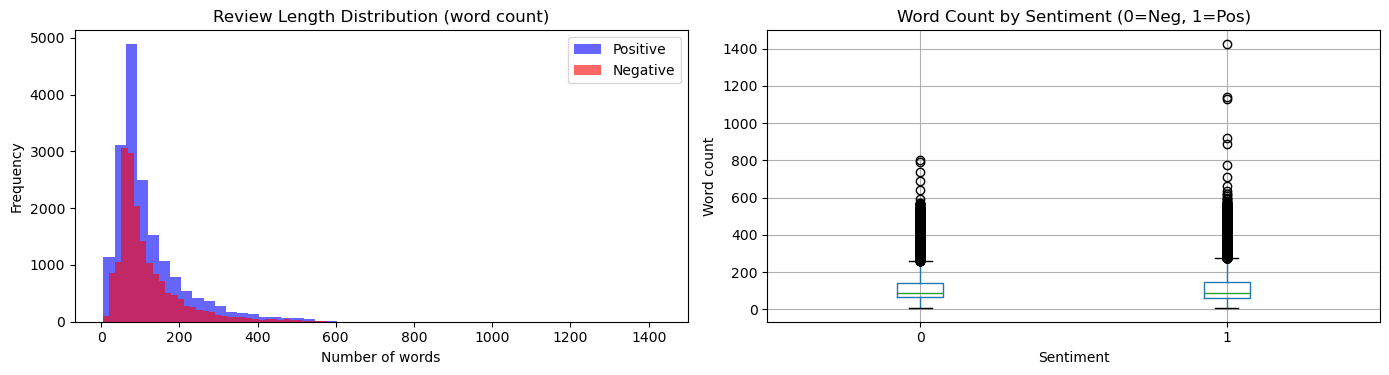

In [6]:
# ----------------------------------------------------------------
# Review Length Distribution
# We count the number of words in each review (after cleaning) and
# compare the distribution for positive vs negative reviews.
# ----------------------------------------------------------------

df_train = pd.DataFrame({'text': X_train_clean, 'label': y_train.values})
df_train['word_count'] = df_train['text'].apply(lambda t: len(t.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of review lengths
axes[0].hist(df_train[df_train.label==1]['word_count'], bins=50, alpha=0.6, label='Positive', color='blue')
axes[0].hist(df_train[df_train.label==0]['word_count'], bins=50, alpha=0.6, label='Negative', color='red')
axes[0].set_title('Review Length Distribution (word count)')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot comparison by sentiment
df_train.boxplot(column='word_count', by='label', ax=axes[1])
axes[1].set_title('Word Count by Sentiment (0=Neg, 1=Pos)')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word count')
plt.suptitle('')
plt.tight_layout()
plt.show()

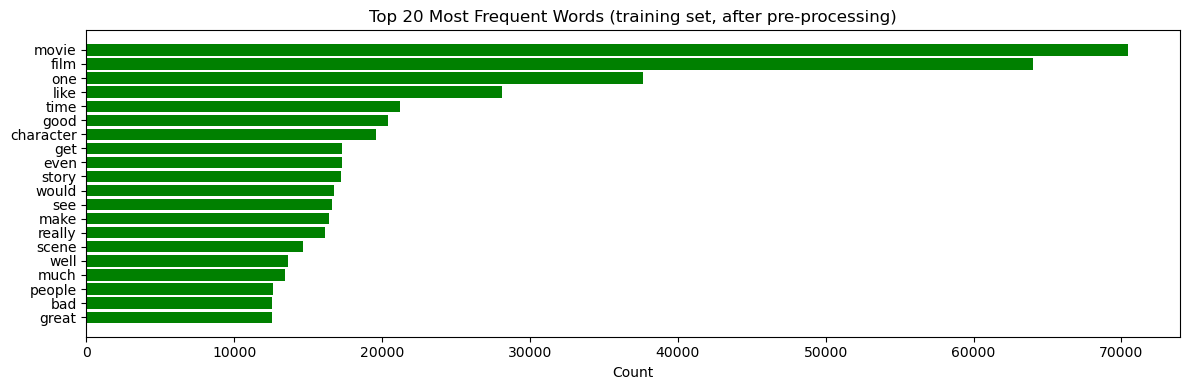

In [7]:
# ----------------------------------------------------------------
# Word Frequency Analysis
# Count the most common words across ALL training reviews.
# ----------------------------------------------------------------

all_words = ' '.join(df_train['text']).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 4))
plt.barh(words[::-1], counts[::-1], color='green')
plt.title('Top 20 Most Frequent Words (training set, after pre-processing)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

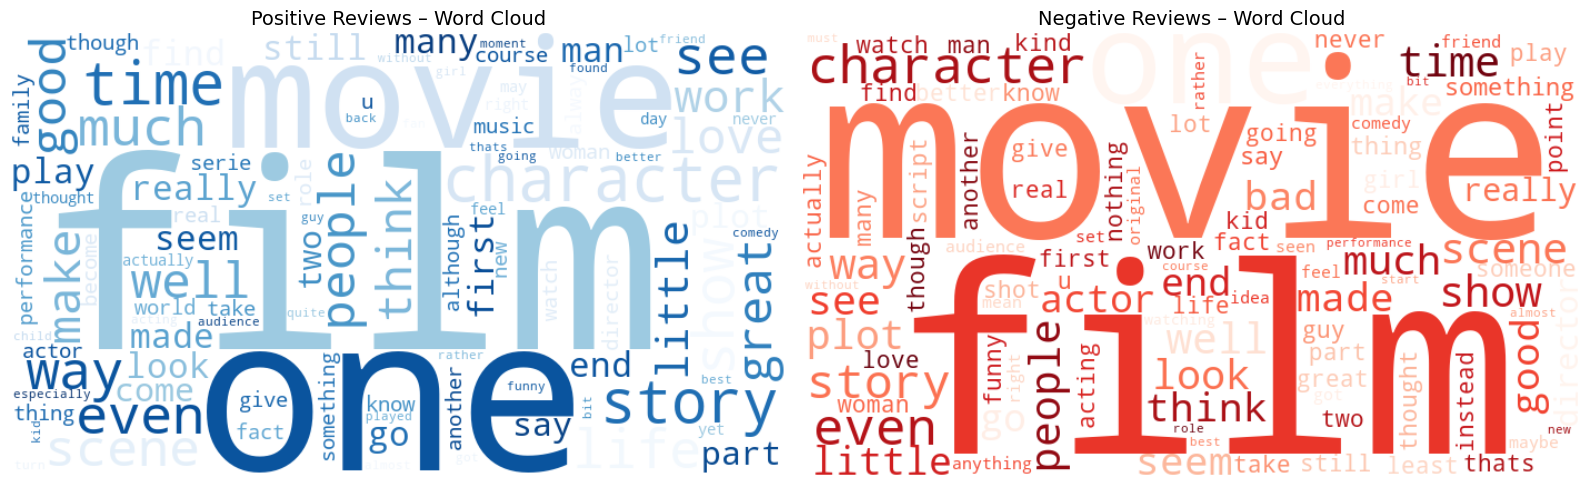

In [8]:
# ----------------------------------------------------------------
# Positive vs Negative Vocabulary Difference
# Word clouds give a visual summary of the most distinctive words
# for each sentiment class.
# ----------------------------------------------------------------

pos_text = ' '.join(df_train[df_train.label==1]['text'])
neg_text = ' '.join(df_train[df_train.label==0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Blues', max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews – Word Cloud', fontsize=14)

wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews – Word Cloud', fontsize=14)

plt.tight_layout()
plt.show()

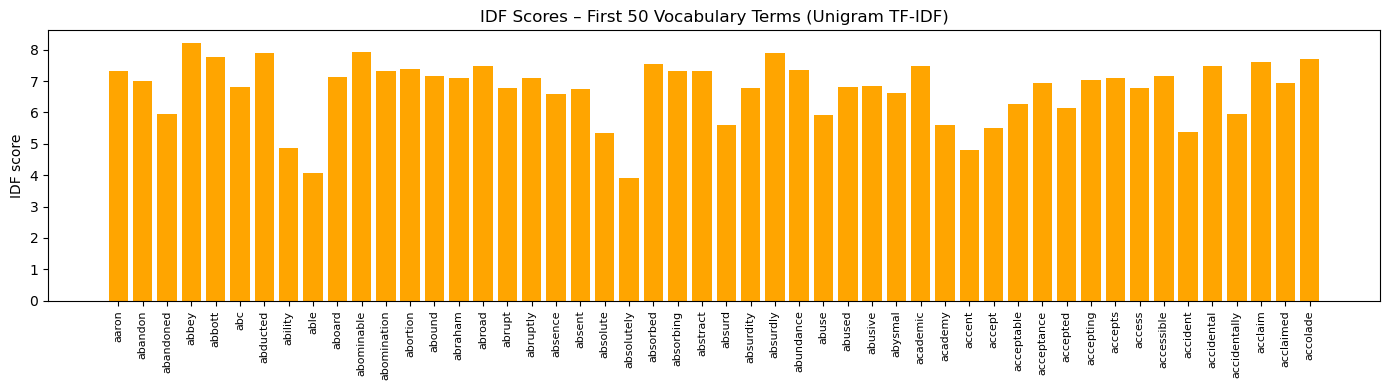

In [9]:
# ----------------------------------------------------------------
# IDF Scores for the First 50 Keywords
# IDF (Inverse Document Frequency) measures how RARE a term is
# across the corpus.  High IDF = the term is rare and potentially
# more informative for distinguishing documents.
# Formula: IDF(t) = log( (1+N) / (1+df(t)) ) + 1  (sklearn default)
# ----------------------------------------------------------------

vocab = tfidf_uni.get_feature_names_out()         # vocabulary list
idf_scores = tfidf_uni.idf_                        # corresponding IDF values

first_50_terms  = vocab[:50]
first_50_idfs   = idf_scores[:50]

plt.figure(figsize=(14, 4))
plt.bar(range(50), first_50_idfs, color='orange')
plt.xticks(range(50), first_50_terms, rotation=90, fontsize=8)
plt.title('IDF Scores – First 50 Vocabulary Terms (Unigram TF-IDF)')
plt.ylabel('IDF score')
plt.tight_layout()
plt.show()

## Q1-e  Logistic Regression, Random Forest, and ANN

In [10]:
# ----------------------------------------------------------------
# Train all three classifiers on BOTH feature representations
# (unigram and bigram TF-IDF) and store results for comparison.
# ----------------------------------------------------------------

from sklearn.neural_network import MLPClassifier   # ANN in sklearn

# Helper: train + evaluate a classifier, return a metrics dict
def evaluate_clf(clf, X_tr, X_te, y_tr, y_te, name):
    clf.fit(X_tr, y_tr)                             # fit on training data
    y_pred  = clf.predict(X_te)                     # predict on test data
    y_prob  = clf.predict_proba(X_te)[:, 1]         # probability of class 1
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_prob),
        'clf'      : clf,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

results_q1 = []

# ---------- Logistic Regression ----------
# A linear classifier.  Fast and strong baseline for text tasks.
for feat_name, Xtr, Xte in [('Unigram', X_train_uni, X_test_uni),
                              ('Bigram',  X_train_bi,  X_test_bi)]:
    r = evaluate_clf(
        LogisticRegression(max_iter=1000, random_state=42),
        Xtr, Xte, y_train, y_test,
        name=f'LogReg-{feat_name}'
    )
    results_q1.append(r)
    print(f"LogReg ({feat_name}) Accuracy: {r['Accuracy']:.4f}")

# ---------- Random Forest ----------
# Ensemble of decision trees.  Robust to overfitting.
for feat_name, Xtr, Xte in [('Unigram', X_train_uni, X_test_uni),
                              ('Bigram',  X_train_bi,  X_test_bi)]:
    r = evaluate_clf(
        RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
        Xtr, Xte, y_train, y_test,
        name=f'RandForest-{feat_name}'
    )
    results_q1.append(r)
    print(f"RandForest ({feat_name}) Accuracy: {r['Accuracy']:.4f}")

# ---------- ANN (MLP) ----------
# Multi-Layer Perceptron with two hidden layers of 256 and 128 units.
# 'relu' activation is standard for hidden layers.
for feat_name, Xtr, Xte in [('Unigram', X_train_uni, X_test_uni),
                              ('Bigram',  X_train_bi,  X_test_bi)]:
    r = evaluate_clf(
        MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu',
                      max_iter=30, random_state=42),
        Xtr, Xte, y_train, y_test,
        name=f'ANN-{feat_name}'
    )
    results_q1.append(r)
    print(f"ANN ({feat_name}) Accuracy: {r['Accuracy']:.4f}")

LogReg (Unigram) Accuracy: 0.8926
LogReg (Bigram) Accuracy: 0.8948
RandForest (Unigram) Accuracy: 0.8540
RandForest (Bigram) Accuracy: 0.8527
ANN (Unigram) Accuracy: 0.8717
ANN (Bigram) Accuracy: 0.8723


## Q1-f  K-NN with Euclidean and Cosine Distance (K = 1 to 25)

K= 1  Euclidean: 0.7259  Cosine: 0.7259
K= 2  Euclidean: 0.7319  Cosine: 0.7319
K= 3  Euclidean: 0.7496  Cosine: 0.7496
K= 4  Euclidean: 0.7553  Cosine: 0.7553
K= 5  Euclidean: 0.7609  Cosine: 0.7609
K= 6  Euclidean: 0.7642  Cosine: 0.7642
K= 7  Euclidean: 0.7673  Cosine: 0.7673
K= 8  Euclidean: 0.7698  Cosine: 0.7698
K= 9  Euclidean: 0.7716  Cosine: 0.7716
K=10  Euclidean: 0.7740  Cosine: 0.7740
K=11  Euclidean: 0.7755  Cosine: 0.7755
K=12  Euclidean: 0.7781  Cosine: 0.7781
K=13  Euclidean: 0.7793  Cosine: 0.7793
K=14  Euclidean: 0.7803  Cosine: 0.7803
K=15  Euclidean: 0.7776  Cosine: 0.7776
K=16  Euclidean: 0.7821  Cosine: 0.7821
K=17  Euclidean: 0.7811  Cosine: 0.7811
K=18  Euclidean: 0.7839  Cosine: 0.7839
K=19  Euclidean: 0.7811  Cosine: 0.7811
K=20  Euclidean: 0.7859  Cosine: 0.7859
K=21  Euclidean: 0.7827  Cosine: 0.7827
K=22  Euclidean: 0.7873  Cosine: 0.7873
K=23  Euclidean: 0.7861  Cosine: 0.7861
K=24  Euclidean: 0.7872  Cosine: 0.7872
K=25  Euclidean: 0.7851  Cosine: 0.7851


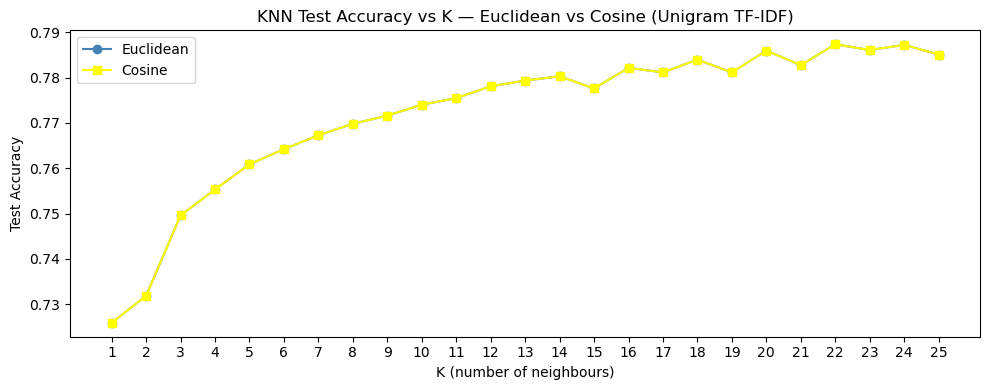

Best K (Euclidean): 22  Acc=0.7873
Best K (Cosine)   : 22  Acc=0.7873


In [11]:
# ----------------------------------------------------------------
# K-Nearest Neighbours classifies a new sample by majority vote
# among its K closest neighbours.
# We sweep K from 1 to 25 and plot test accuracy for each K.
# ----------------------------------------------------------------

# Use unigram TF-IDF for KNN (more manageable dimensionality)
k_range = range(1, 26)
scores_euclidean = []
scores_cosine    = []

for k in k_range:
    # Euclidean distance (metric='minkowski', p=2 is default)
    knn_euc = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn_euc.fit(X_train_uni, y_train)
    scores_euclidean.append(accuracy_score(y_test, knn_euc.predict(X_test_uni)))

    # Cosine similarity  (distance = 1 – cosine_similarity)
    knn_cos = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn_cos.fit(X_train_uni, y_train)
    scores_cosine.append(accuracy_score(y_test, knn_cos.predict(X_test_uni)))

    print(f'K={k:2d}  Euclidean: {scores_euclidean[-1]:.4f}  Cosine: {scores_cosine[-1]:.4f}')

# Plot validation accuracy vs K
plt.figure(figsize=(10, 4))
plt.plot(k_range, scores_euclidean, 'o-', label='Euclidean', color='steelblue')
plt.plot(k_range, scores_cosine,    's-', label='Cosine',    color='yellow')
plt.xlabel('K (number of neighbours)')
plt.ylabel('Test Accuracy')
plt.title('KNN Test Accuracy vs K — Euclidean vs Cosine (Unigram TF-IDF)')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()

best_k_euc = k_range[np.argmax(scores_euclidean)]
best_k_cos = k_range[np.argmax(scores_cosine)]
print(f'Best K (Euclidean): {best_k_euc}  Acc={max(scores_euclidean):.4f}')
print(f'Best K (Cosine)   : {best_k_cos}  Acc={max(scores_cosine):.4f}')

In [12]:
# Add the best KNN results to our results list for comparison
knn_best_euc = KNeighborsClassifier(n_neighbors=best_k_euc, metric='euclidean', n_jobs=-1)
knn_best_euc.fit(X_train_uni, y_train)
results_q1.append(evaluate_clf(knn_best_euc, X_train_uni, X_test_uni, y_train, y_test,
                                name=f'KNN-Euclidean(K={best_k_euc})'))

knn_best_cos = KNeighborsClassifier(n_neighbors=best_k_cos, metric='cosine', n_jobs=-1)
knn_best_cos.fit(X_train_uni, y_train)
results_q1.append(evaluate_clf(knn_best_cos, X_train_uni, X_test_uni, y_train, y_test,
                                name=f'KNN-Cosine(K={best_k_cos})'))

## Q1-g  Comparison 

In [13]:
# ----------------------------------------------------------------
# Summary metrics table for every model
# ----------------------------------------------------------------

metrics_df = pd.DataFrame([{
    'Model'    : r['Model'],
    'Accuracy' : round(r['Accuracy'],  4),
    'Precision': round(r['Precision'], 4),
    'Recall'   : round(r['Recall'],    4),
    'F1'       : round(r['F1'],        4),
    'ROC-AUC'  : round(r['ROC-AUC'],  4),
} for r in results_q1])

print(metrics_df.to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
     LogReg-Unigram    0.8926     0.8847  0.9029 0.8937   0.9582
      LogReg-Bigram    0.8948     0.8869  0.9051 0.8959   0.9601
 RandForest-Unigram    0.8540     0.8592  0.8468 0.8529   0.9297
  RandForest-Bigram    0.8527     0.8554  0.8489 0.8522   0.9306
        ANN-Unigram    0.8717     0.8688  0.8756 0.8722   0.9419
         ANN-Bigram    0.8723     0.8682  0.8777 0.8730   0.9443
KNN-Euclidean(K=22)    0.7873     0.7738  0.8121 0.7925   0.8629
   KNN-Cosine(K=22)    0.7873     0.7738  0.8121 0.7925   0.8629


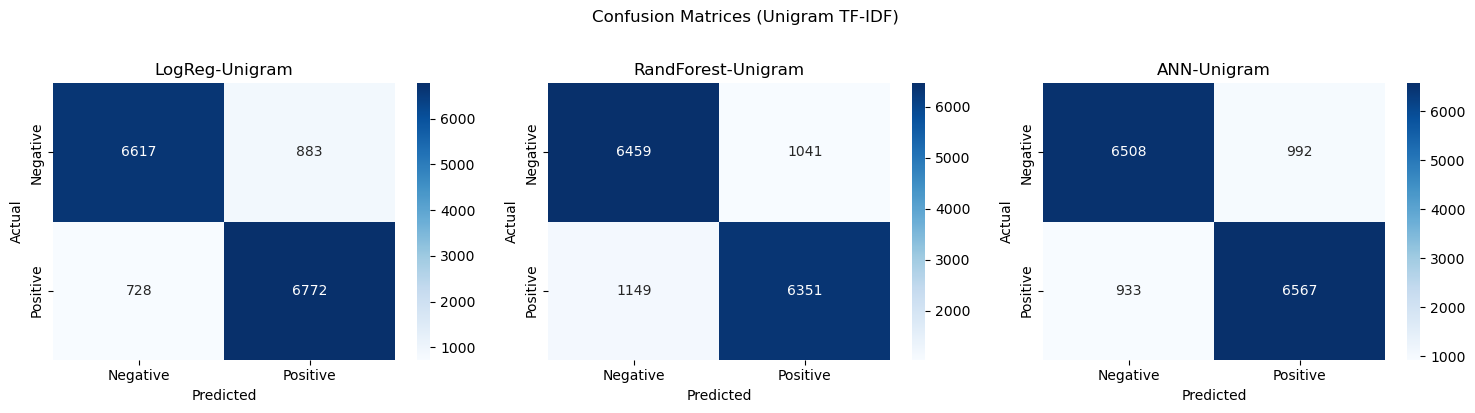

In [14]:
# ----------------------------------------------------------------
# Confusion matrices for the three primary classifiers (unigram)
# A confusion matrix shows:
#   TN  FP     (row 0 = true negatives / false positives)
#   FN  TP     (row 1 = false negatives / true positives)
# ----------------------------------------------------------------

primary = ['LogReg-Unigram', 'RandForest-Unigram', 'ANN-Unigram']
primary_res = [r for r in results_q1 if r['Model'] in primary]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, r in zip(axes, primary_res):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    ax.set_title(r['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices (Unigram TF-IDF)', y=1.02)
plt.tight_layout()
plt.show()

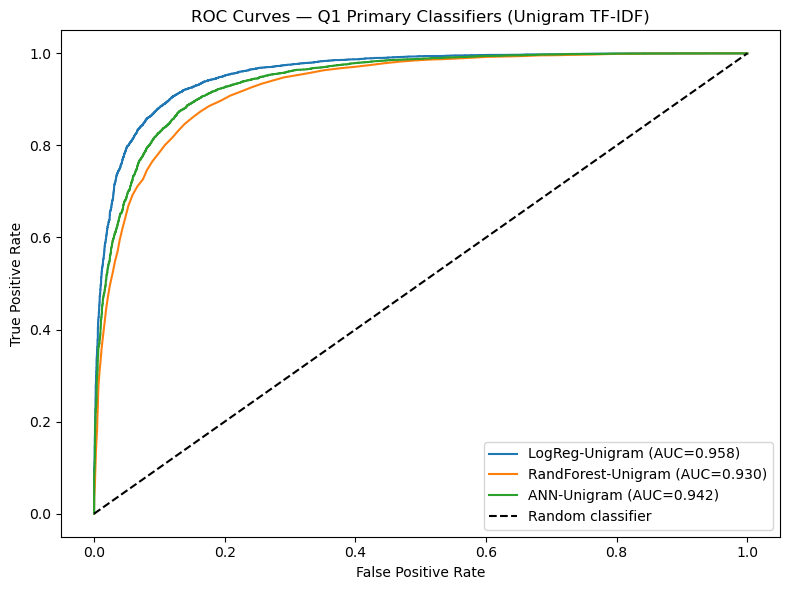

In [15]:
# ----------------------------------------------------------------
# ROC Curves
# ROC = Receiver Operating Characteristic.
# Each curve plots True Positive Rate vs False Positive Rate as the
# classification threshold varies.  AUC close to 1 is better.
# ----------------------------------------------------------------

plt.figure(figsize=(8, 6))
for r in primary_res:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Q1 Primary Classifiers (Unigram TF-IDF)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
# QUESTION 2 — Multi-Class Emotion Classification
---

## Q2-a  Load the Emotion Dataset

In [16]:
from pathlib import Path

# ----------------------------------------------------------------
# The emotions.zip file contains three tab/semicolon-separated text
# files: train.txt, test.txt, val.txt
# Each line is: "sentence text;emotion_label"
# ----------------------------------------------------------------

def load_emotion_split(zip_path, filename):
    """Read one split from the zip archive into a DataFrame."""
    with zipfile.ZipFile(zip_path) as z:
        with z.open(f'emotions/{filename}') as f:
            lines = f.read().decode('utf-8').strip().split('\n')
    records = []
    for line in lines:
        parts = line.rsplit(';', 1)   # split on LAST semicolon
        if len(parts) == 2:
            records.append({'text': parts[0].strip(), 'emotion': parts[1].strip()})
    return pd.DataFrame(records)

ZIP_PATH = 'emotions.zip'   # adjust if in a different directory

ZIP_PATH = Path('emotions.zip')

if not ZIP_PATH.exists():
    matches = list(Path.cwd().rglob('emotions.zip'))
    if matches:
        ZIP_PATH = matches[0]
    else:
        search_roots = [Path.cwd(), *Path.cwd().parents]
        for root in search_roots:
            matches = list(root.rglob('emotions.zip'))
            if matches:
                ZIP_PATH = matches[0]
                print(f'Found emotions.zip at: {ZIP_PATH}')
                break
        else:
            raise FileNotFoundError(
            "emotions.zip not found. Place it in the notebook folder or update ZIP_PATH."
            )

df_train_em = load_emotion_split(ZIP_PATH, 'train.txt')
df_test_em  = load_emotion_split(ZIP_PATH, 'test.txt')
df_val_em   = load_emotion_split(ZIP_PATH, 'val.txt')

print('Train:', df_train_em.shape)
print('Test :', df_test_em.shape)
print('Val  :', df_val_em.shape)
df_train_em.head(5)

Train: (16000, 2)
Test : (2000, 2)
Val  : (2000, 2)


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## Q2-b  Dataset Statistics and Exploratory Analysis

In [17]:
# ----------------------------------------------------------------
# Dimensions, class distribution, missing values, duplicates
# ----------------------------------------------------------------

for split_name, df_split in [('Train', df_train_em), ('Test', df_test_em), ('Val', df_val_em)]:
    print(f'--- {split_name} ---')
    print('  Dimensions :', df_split.shape)
    print('  Missing    :', df_split.isnull().sum().to_dict())
    print('  Duplicates :', df_split.duplicated().sum())
    print('  Class dist :\n', df_split['emotion'].value_counts().to_string(), '\n')

--- Train ---
  Dimensions : (16000, 2)
  Missing    : {'text': 0, 'emotion': 0}
  Duplicates : 1
  Class dist :
 emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572 

--- Test ---
  Dimensions : (2000, 2)
  Missing    : {'text': 0, 'emotion': 0}
  Duplicates : 0
  Class dist :
 emotion
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66 

--- Val ---
  Dimensions : (2000, 2)
  Missing    : {'text': 0, 'emotion': 0}
  Duplicates : 0
  Class dist :
 emotion
joy         704
sadness     550
anger       275
fear        212
love        178
surprise     81 



In [18]:
# ----------------------------------------------------------------
# Average sentence length per emotion class
# ----------------------------------------------------------------

df_train_em['sent_len'] = df_train_em['text'].apply(lambda t: len(t.split()))
print('Average sentence length by emotion:')
print(df_train_em.groupby('emotion')['sent_len'].mean().sort_values(ascending=False))

Average sentence length by emotion:
emotion
love        20.700153
surprise    19.970280
joy         19.498135
anger       19.229736
fear        18.844605
sadness     18.361980
Name: sent_len, dtype: float64


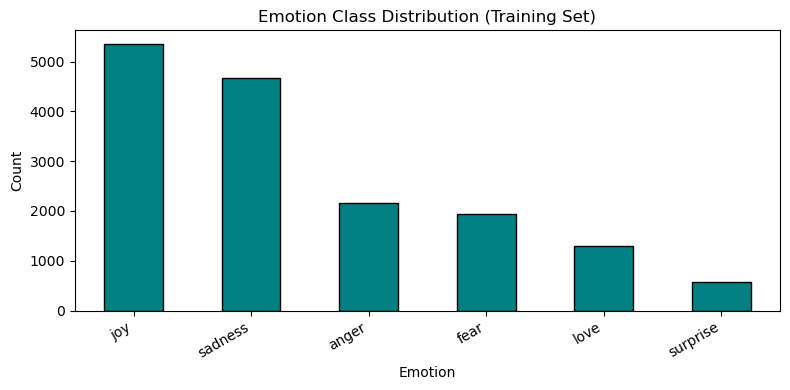

In [19]:
# ----------------------------------------------------------------
# Class imbalance visualisation
# ----------------------------------------------------------------

emotion_counts = df_train_em['emotion'].value_counts()

plt.figure(figsize=(8, 4))
emotion_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Emotion Class Distribution (Training Set)')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

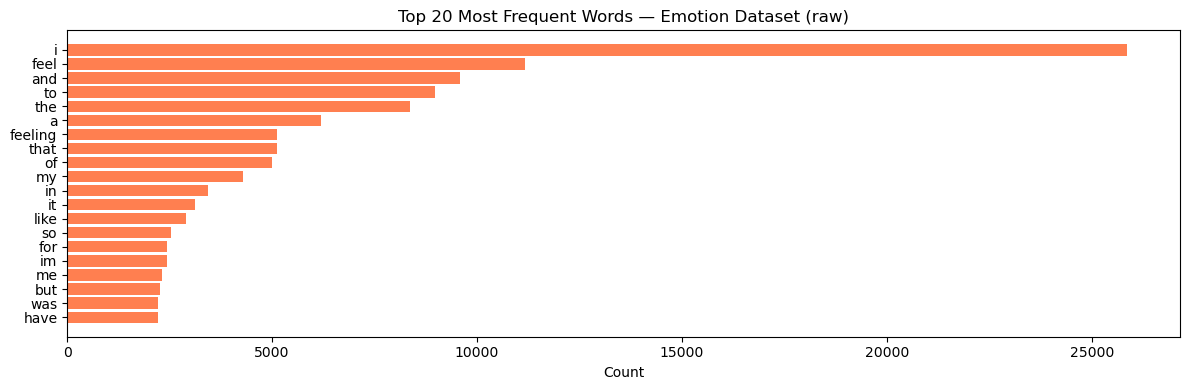

In [20]:
# ----------------------------------------------------------------
# Most frequent words across the full training corpus
# ----------------------------------------------------------------

all_em_words = ' '.join(df_train_em['text']).split()
top_em_words = Counter(all_em_words).most_common(20)
w, c = zip(*top_em_words)
plt.figure(figsize=(12, 4))
plt.barh(w[::-1], c[::-1], color='coral')
plt.title('Top 20 Most Frequent Words — Emotion Dataset (raw)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

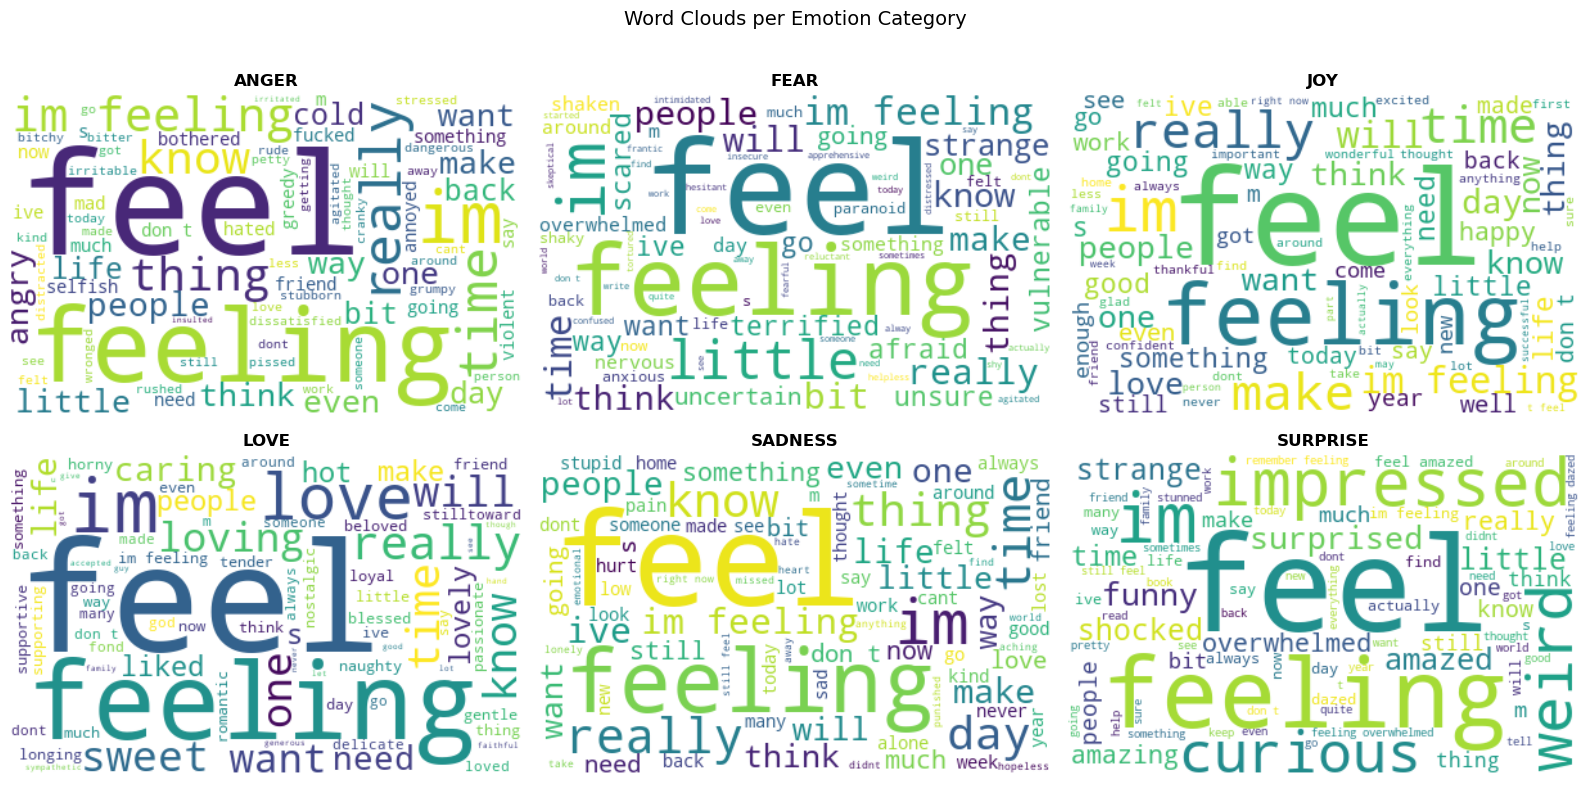

In [21]:
# ----------------------------------------------------------------
# Word clouds for each emotion category
# ----------------------------------------------------------------

emotions = df_train_em['emotion'].unique()
n_em = len(emotions)
fig, axes = plt.subplots(2, (n_em + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for i, emo in enumerate(sorted(emotions)):
    emo_text = ' '.join(df_train_em[df_train_em.emotion == emo]['text'])
    wc = WordCloud(width=400, height=250, background_color='white',
                   max_words=80).generate(emo_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(emo.upper(), fontsize=12, fontweight='bold')

# Hide unused subplots if number is odd
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Word Clouds per Emotion Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Q2-c  Text Pre-processing

In [22]:
# ----------------------------------------------------------------
# Reuse the preprocess() function defined in Q1-b.
# We pre-process all three splits.
# ----------------------------------------------------------------

print('Cleaning training set...')
df_train_em['clean'] = df_train_em['text'].apply(preprocess)
print('Cleaning test set...')
df_test_em['clean']  = df_test_em['text'].apply(preprocess)
print('Cleaning val set...')
df_val_em['clean']   = df_val_em['text'].apply(preprocess)

# Encode emotion labels as integers (required by sklearn + Keras)
le = LabelEncoder()
y_train_em = le.fit_transform(df_train_em['emotion'])   # fit only on training
y_test_em  = le.transform(df_test_em['emotion'])
y_val_em   = le.transform(df_val_em['emotion'])

print('Classes:', le.classes_)

Cleaning training set...
Cleaning test set...
Cleaning val set...
Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


## Q2-d Top 500 Terms from Training Corpus

In [23]:
# ----------------------------------------------------------------
# Build a vocabulary of the 500 most frequent terms from the
# TRAINING corpus only.  We then use this fixed vocabulary
# for all feature representations (BoW, TF-IDF).
# ----------------------------------------------------------------

all_train_tokens = ' '.join(df_train_em['clean']).split()
vocab_500 = [w for w, _ in Counter(all_train_tokens).most_common(500)]

print(f'Vocabulary size: {len(vocab_500)}')
print('Sample terms:', vocab_500[:20])

Vocabulary size: 500
Sample terms: ['feel', 'feeling', 'like', 'im', 'time', 'really', 'know', 'get', 'make', 'little', 'want', 'day', 'thing', 'people', 'one', 'would', 'think', 'life', 'still', 'ive']


## Q2-e  Feature Representations

In [24]:
# ----------------------------------------------------------------
# 1. Bag-of-Words (BoW)
#    Simple word count matrix.  Each column = one vocabulary term.
#    Each cell = how many times that term appears in a document.
# ----------------------------------------------------------------

bow_vec = CountVectorizer(vocabulary=vocab_500)
X_train_bow = bow_vec.fit_transform(df_train_em['clean'])
X_test_bow  = bow_vec.transform(df_test_em['clean'])
X_val_bow   = bow_vec.transform(df_val_em['clean'])

print('BoW shapes:', X_train_bow.shape, X_test_bow.shape)

BoW shapes: (16000, 500) (2000, 500)


In [25]:
# ----------------------------------------------------------------
# 2. TF-IDF (same vocabulary of 500 terms)
# ----------------------------------------------------------------

tfidf_em = TfidfVectorizer(vocabulary=vocab_500)
X_train_tfidf_em = tfidf_em.fit_transform(df_train_em['clean'])
X_test_tfidf_em  = tfidf_em.transform(df_test_em['clean'])
X_val_tfidf_em   = tfidf_em.transform(df_val_em['clean'])

print('TF-IDF shapes:', X_train_tfidf_em.shape, X_test_tfidf_em.shape)

TF-IDF shapes: (16000, 500) (2000, 500)


In [26]:
# ----------------------------------------------------------------
# 3. Word Embeddings (GloVe – pre-trained)
# Each word maps to a dense 100-dimensional vector.
# A document is represented by the AVERAGE of its word vectors.
#
# To use this cell you need the GloVe file:
#   glove.6B.100d.txt  (download from https://nlp.stanford.edu/projects/glove/)
# and set GLOVE_PATH below.
# If GloVe is unavailable we fall back to a zero-vector representation.
# ----------------------------------------------------------------

GLOVE_PATH = 'glove.6B.100d.txt'   # <-- set your path here
EMBED_DIM  = 100

def load_glove(path):
    """Load GloVe into a word → vector dictionary."""
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word  = parts[0]
            vec   = np.array(parts[1:], dtype='float32')
            embeddings[word] = vec
    return embeddings

def doc_to_avg_embedding(text, embed_dict, dim=EMBED_DIM):
    """Average the embedding vectors of all recognised words in text."""
    vecs = [embed_dict[w] for w in text.split() if w in embed_dict]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

import os
if os.path.exists(GLOVE_PATH):
    print('Loading GloVe...')
    glove = load_glove(GLOVE_PATH)
    X_train_emb = np.vstack([doc_to_avg_embedding(t, glove) for t in df_train_em['clean']])
    X_test_emb  = np.vstack([doc_to_avg_embedding(t, glove) for t in df_test_em['clean']])
    X_val_emb   = np.vstack([doc_to_avg_embedding(t, glove) for t in df_val_em['clean']])
    print('Embedding matrix shapes:', X_train_emb.shape, X_test_emb.shape)
else:
    print(f'GloVe file not found at {GLOVE_PATH}.  Using zero embeddings as placeholder.')
    n_tr = len(df_train_em); n_te = len(df_test_em); n_va = len(df_val_em)
    X_train_emb = np.zeros((n_tr, EMBED_DIM))
    X_test_emb  = np.zeros((n_te, EMBED_DIM))
    X_val_emb   = np.zeros((n_va, EMBED_DIM))

GloVe file not found at glove.6B.100d.txt.  Using zero embeddings as placeholder.


## Q2-f  Classifiers + Hyperparameter Tuning

In [27]:
# ----------------------------------------------------------------
# We train three classifiers on TF-IDF features.
# Hyperparameter tuning is applied to Decision Tree and
# Random Forest using GridSearchCV.
#
# GridSearchCV exhaustively tests all parameter combinations
# using cross-validation and picks the best configuration.
# ----------------------------------------------------------------

from sklearn.neural_network import MLPClassifier

# ---- 1. Decision Tree with GridSearchCV ----
dt_param_grid = {
    'max_depth'       : [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid, cv=3, scoring='f1_macro', n_jobs=-1
)
dt_grid.fit(X_train_tfidf_em, y_train_em)
best_dt = dt_grid.best_estimator_
print('Best DT params:', dt_grid.best_params_)

Best DT params: {'max_depth': None, 'min_samples_leaf': 10}


In [28]:
# 2. Random Forest with RandomizedSearchCV ----
# RandomizedSearchCV samples a fixed number of parameter combinations
# at random — faster than GridSearchCV when the search space is large.

from scipy.stats import randint

rf_param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth'   : [5, 10, 20, None],
    'max_features': ['sqrt', 'log2']
}
rf_rand = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist, n_iter=10, cv=3, scoring='f1_macro',
    random_state=42, n_jobs=-1
)
rf_rand.fit(X_train_tfidf_em, y_train_em)
best_rf = rf_rand.best_estimator_
print('Best RF params:', rf_rand.best_params_)

Best RF params: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 180}


In [29]:
# ---- 3. ANN (MLP) ----
ann_em = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu',
                        max_iter=50, random_state=42)
ann_em.fit(X_train_tfidf_em, y_train_em)
print('ANN trained.')

ANN trained.


## Q2-g  Evaluation + Predict New Sentences

In [30]:
# ----------------------------------------------------------------
# Evaluate all three models on the test set.
# Macro-F1 averages F1 equally across all classes (good for
# imbalanced datasets because it does not weight by support).
# ----------------------------------------------------------------

def eval_multiclass(clf, X_te, y_te, name):
    y_pred = clf.predict(X_te)
    return {
        'Model'       : name,
        'Accuracy'    : round(accuracy_score(y_te, y_pred), 4),
        'Macro-Prec'  : round(precision_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Macro-Recall': round(recall_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Macro-F1'    : round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'y_pred'      : y_pred,
    }

results_em = [
    eval_multiclass(best_dt, X_test_tfidf_em, y_test_em, 'DecisionTree'),
    eval_multiclass(best_rf, X_test_tfidf_em, y_test_em, 'RandomForest'),
    eval_multiclass(ann_em,  X_test_tfidf_em, y_test_em, 'ANN-MLP'),
]

metrics_em = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred'} for r in results_em])
print(metrics_em.to_string(index=False))

       Model  Accuracy  Macro-Prec  Macro-Recall  Macro-F1
DecisionTree    0.6215      0.5897        0.5511    0.5660
RandomForest    0.6490      0.6354        0.5514    0.5810
     ANN-MLP    0.6245      0.5801        0.5509    0.5617


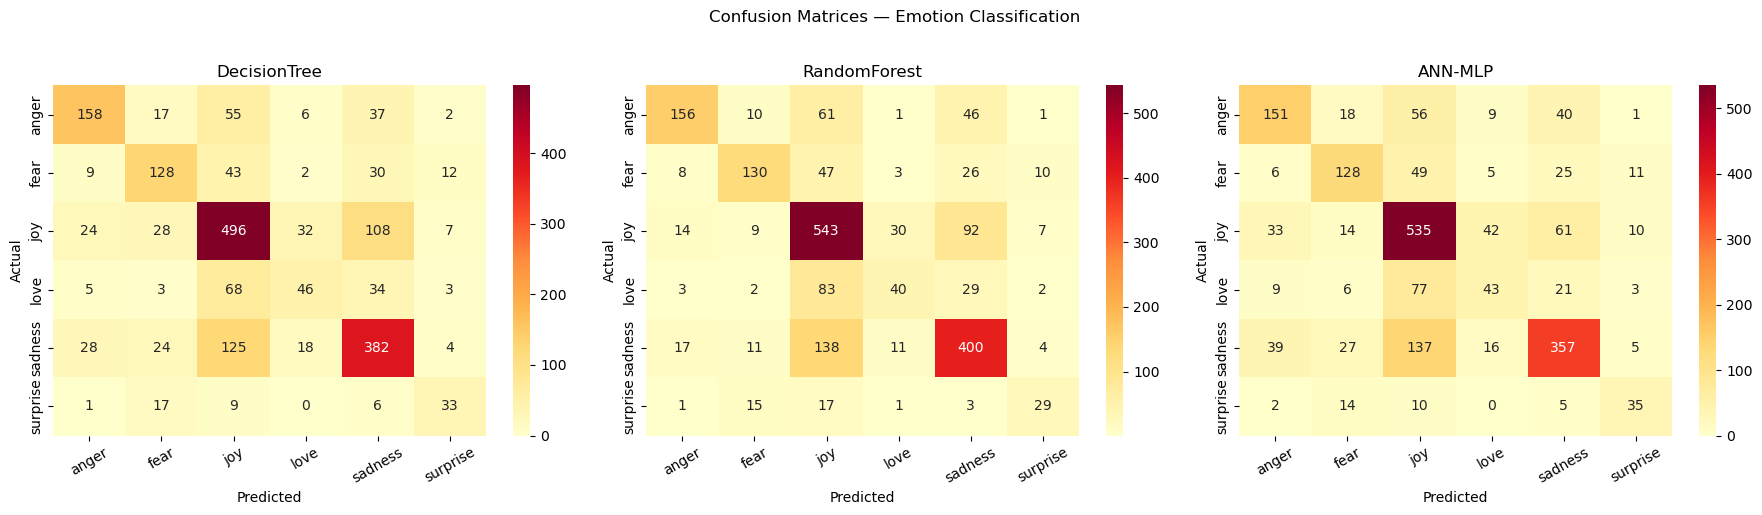

In [31]:
# ----------------------------------------------------------------
# Confusion matrices for all three classifiers
# ----------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = le.classes_

for ax, r in zip(axes, results_em):
    cm = confusion_matrix(y_test_em, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(r['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — Emotion Classification', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
# ----------------------------------------------------------------
# Predict emotions for 5 new sentences using the best classifier
# (the one with the highest Macro-F1).
# ----------------------------------------------------------------

best_em_model_name = metrics_em.loc[metrics_em['Macro-F1'].idxmax(), 'Model']
best_em_clf = {'DecisionTree': best_dt, 'RandomForest': best_rf,
               'ANN-MLP': ann_em}[best_em_model_name]
print(f'Best model: {best_em_model_name}')

new_sentences = [
    "I feel completely devastated after losing my wallet.",
    "I am excited about my graduation ceremony.",
    "Everything feels so gloomy and I cannot stop crying.",
    "I was furious when they cancelled our plans at the last minute.",
    "There is a warm sense of gratitude in my heart today.",
]

# Pre-process each new sentence, then transform with the same TF-IDF
new_clean  = [preprocess(s) for s in new_sentences]
new_feats  = tfidf_em.transform(new_clean)
predictions = best_em_clf.predict(new_feats)
pred_labels = le.inverse_transform(predictions)

pred_df = pd.DataFrame({'Sentence': new_sentences, 'Predicted Emotion': pred_labels})
print(pred_df.to_string(index=False))

Best model: RandomForest
                                                       Sentence Predicted Emotion
           I feel completely devastated after losing my wallet.           sadness
                     I am excited about my graduation ceremony.               joy
           Everything feels so gloomy and I cannot stop crying.           sadness
I was furious when they cancelled our plans at the last minute.               joy
          There is a warm sense of gratitude in my heart today.              fear


## Q2-h  Dimensionality Reduction with PCA — 2D Emotion Clusters

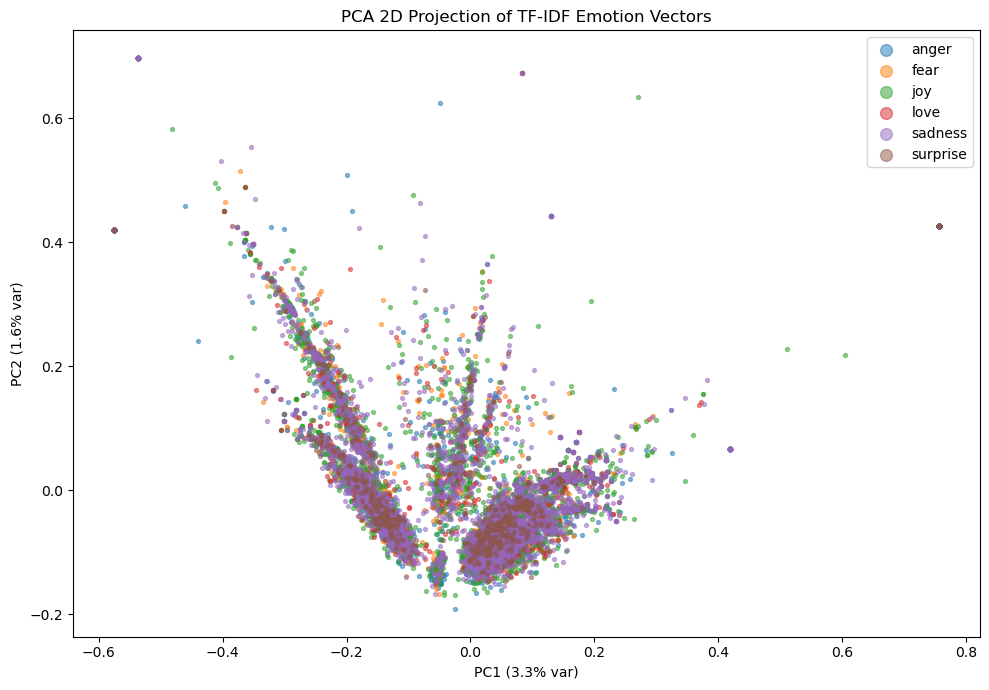

In [33]:
# ----------------------------------------------------------------
# PCA (Principal Component Analysis) reduces high-dimensional
# TF-IDF vectors to 2D so we can plot them.
# Each colour = one emotion category.
# ----------------------------------------------------------------

pca2 = PCA(n_components=2, random_state=42)
# PCA cannot work directly on sparse matrices → convert to dense (.toarray())
X_pca2 = pca2.fit_transform(X_train_tfidf_em.toarray())

palette = sns.color_palette('tab10', n_colors=len(le.classes_))
color_map = dict(zip(le.classes_, palette))

plt.figure(figsize=(10, 7))
for emo in le.classes_:
    mask = df_train_em['emotion'].values == emo
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                s=8, alpha=0.5, color=color_map[emo], label=emo)

plt.title('PCA 2D Projection of TF-IDF Emotion Vectors')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(markerscale=3, loc='upper right')
plt.tight_layout()
plt.show()

## Q2-i  K-Means Clustering (K = 3 to 10)

K=3  Inertia=4247.2  Silhouette=0.0823
K=4  Inertia=4203.6  Silhouette=0.0830
K=5  Inertia=4136.6  Silhouette=0.0863
K=6  Inertia=4055.6  Silhouette=0.0860
K=7  Inertia=3996.3  Silhouette=0.0898
K=8  Inertia=3625.7  Silhouette=0.1204
K=9  Inertia=3567.2  Silhouette=0.1242
K=10  Inertia=3496.1  Silhouette=0.1313


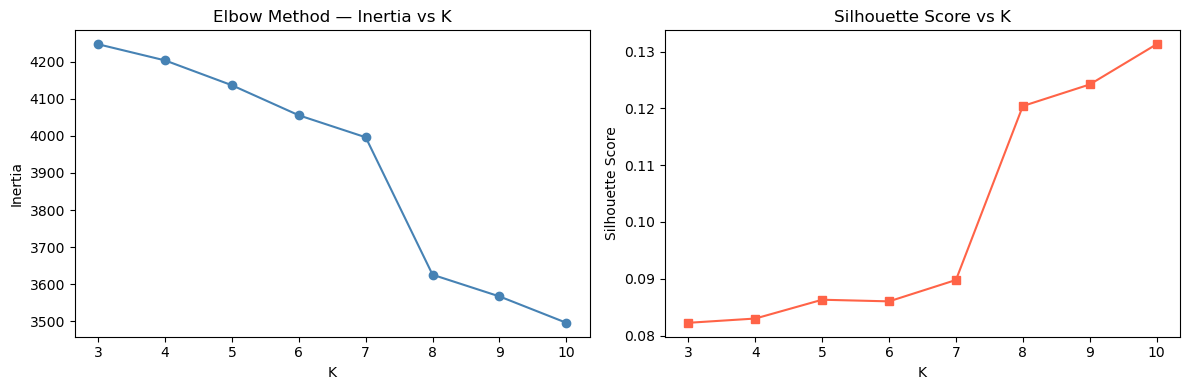

Optimal K (highest silhouette): 10


In [ ]:
# ----------------------------------------------------------------
# K-Means
# Elbow Method
# Silhouette Score
# ----------------------------------------------------------------

inertias    = []
silhouettes = []
K_range     = range(3, 11)

# Reduce to 50 dims first for speed (PCA does not distort clustering much)
pca50 = PCA(n_components=50, random_state=42)
X_50  = pca50.fit_transform(X_train_tfidf_em.toarray())

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_50)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_50, km.labels_, sample_size=2000, random_state=42)
    silhouettes.append(sil)
    print(f'K={k}  Inertia={km.inertia_:.1f}  Silhouette={sil:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 's-', color='tomato')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f'Optimal K (highest silhouette): {optimal_k}')

In [35]:
# ----------------------------------------------------------------
# Show cluster membership for the test documents using optimal K
# ----------------------------------------------------------------

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
km_final.fit(X_50)

# Transform test set to same 50-dim PCA space, then assign clusters
X_test_50    = pca50.transform(X_test_tfidf_em.toarray())
test_clusters = km_final.predict(X_test_50)

df_test_em['cluster'] = test_clusters
print('Test set cluster distribution:')
print(df_test_em['cluster'].value_counts().sort_index())

Test set cluster distribution:
cluster
0    870
1     48
2    508
3    243
4     39
5     48
6     77
7     26
8     61
9     80
Name: count, dtype: int64


---
# QUESTION 3 — Medical Image Caption Retrieval
---

## Q3-a  Load the Caption Data

In [ ]:
# ----------------------------------------------------------------
# The file is tab-separated with columns: ID  caption
# ----------------------------------------------------------------

df_caps = pd.read_csv('image_caption.txt', sep='\t')
df_caps.columns = df_caps.columns.str.strip()   # clean any leading spaces

print('Shape:', df_caps.shape)
df_caps.head(4)

Shape: (1000, 2)


,ID,caption
0,ImageCLEFmedCaption_2022_train_000001,pericardial tamponade with clear distinction o...
1,ImageCLEFmedCaption_2022_train_000002,angiography of the aortic arch show delay visu...
2,ImageCLEFmedCaption_2022_train_000003,balloonocclude retrograde transvenous oblitera...
3,ImageCLEFmedCaption_2022_train_000004,film after glue embolization show no filling i...


## Q3-b  Pre-processing

In [37]:
# ----------------------------------------------------------------
# Lighter pre-processing for medical text:
#   - lowercase
#   - remove punctuation and numbers
#   - remove stop words
# We do NOT stem/lemmatize aggressively — medical terms are precise.
# ----------------------------------------------------------------

def preprocess_medical(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df_caps['clean'] = df_caps['caption'].astype(str).apply(preprocess_medical)
df_caps.head(3)

,ID,caption,clean
0,ImageCLEFmedCaption_2022_train_000001,pericardial tamponade with clear distinction o...,pericardial tamponade clear distinction epicar...
1,ImageCLEFmedCaption_2022_train_000002,angiography of the aortic arch show delay visu...,angiography aortic arch show delay visualizati...
2,ImageCLEFmedCaption_2022_train_000003,balloonocclude retrograde transvenous oblitera...,balloonocclude retrograde transvenous oblitera...


## Q3-c  Term-Document Matrix with TF-IDF

In [38]:
# ----------------------------------------------------------------
# The Term-Document Matrix has:
#   rows    = documents (1000 captions)
#   columns = vocabulary terms
#   values  = TF-IDF weight
# ----------------------------------------------------------------

tfidf_med = TfidfVectorizer(max_features=5000)
TDM = tfidf_med.fit_transform(df_caps['clean'])

print('Term-Document Matrix shape:', TDM.shape,
      '  (rows=documents, cols=terms)')

Term-Document Matrix shape: (1000, 2645)   (rows=documents, cols=terms)


## Q3-d  TF-IDF + Cosine Similarity Retrieval

In [39]:
# ----------------------------------------------------------------
# Retrieval pipeline:
#   1. Pre-process the query text
#   2. Convert to TF-IDF vector using the FITTED vectorizer
#   3. Compute cosine similarity between query and all documents
#   4. Return the top-K most similar captions
# ----------------------------------------------------------------

def retrieve_tfidf(query: str, tdm, vectorizer, df, top_k=10):
    """Return the top-K captions most similar to the query (TF-IDF)."""
    q_clean = preprocess_medical(query)
    q_vec   = vectorizer.transform([q_clean])       # sparse (1, V)
    sims    = cosine_similarity(q_vec, tdm).flatten()  # shape (N,)
    top_idx = np.argsort(sims)[::-1][:top_k]        # descending order
    results = df.iloc[top_idx][['ID', 'caption']].copy()
    results['cosine_sim'] = sims[top_idx]
    return results.reset_index(drop=True)

Q1 = "angiographic image shows normal coronary artery"
Q2 = "CT scan demonstrating pulmonary embolism"

print('=== TF-IDF Results for Q1 ===')
res_q1_tfidf = retrieve_tfidf(Q1, TDM, tfidf_med, df_caps)
print(res_q1_tfidf.to_string(index=False))

print('\n=== TF-IDF Results for Q2 ===')
res_q2_tfidf = retrieve_tfidf(Q2, TDM, tfidf_med, df_caps)
print(res_q2_tfidf.to_string(index=False))

=== TF-IDF Results for Q1 ===
                                   ID                                                                                                                                                                         caption  cosine_sim
ImageCLEFmedCaption_2022_train_000019                                                                                                                                  angiographic image show normal coronary artery    0.966911
ImageCLEFmedCaption_2022_train_000756                                                                                                                                                    normal leave coronary artery    0.660022
ImageCLEFmedCaption_2022_train_000382                                                                                                                  coronary angiography with normal coronary angiographic finding    0.657725
ImageCLEFmedCaption_2022_train_000755                             

## Q3-e  GloVe Embedding Retrieval

In [40]:
# ----------------------------------------------------------------
# Word embedding retrieval:
#   - Each caption → average of its word vectors
#   - Query  → average of its word vectors
#   - Rank by cosine similarity between query and caption vectors
#
# This can surface semantically related captions even when the
# exact query words are absent (e.g. 'embolism' ~ 'thrombosis').
# ----------------------------------------------------------------

# Compute embeddings for all captions (falls back to zeros if GloVe absent)
import os
if os.path.exists(GLOVE_PATH):
    if 'glove' not in dir():
        glove = load_glove(GLOVE_PATH)
    cap_embeddings = np.vstack([
        doc_to_avg_embedding(t, glove) for t in df_caps['clean']
    ])
else:
    print('GloVe not found — embedding retrieval will return zero-distance results.')
    cap_embeddings = np.zeros((len(df_caps), EMBED_DIM))

def retrieve_glove(query: str, cap_embs, embed_dict, df, top_k=10):
    """Return the top-K captions by GloVe embedding cosine similarity."""
    q_vec = doc_to_avg_embedding(preprocess_medical(query), embed_dict)
    if np.all(q_vec == 0):
        print('Warning: no GloVe coverage for query.')
        return df.head(top_k)
    sims    = cosine_similarity(q_vec.reshape(1, -1), cap_embs).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    results = df.iloc[top_idx][['ID', 'caption']].copy()
    results['cosine_sim'] = sims[top_idx]
    return results.reset_index(drop=True)

print('=== GloVe Results for Q1 ===')
res_q1_glove = retrieve_glove(Q1, cap_embeddings, glove if os.path.exists(GLOVE_PATH) else {}, df_caps)
print(res_q1_glove.to_string(index=False))

print('\n=== GloVe Results for Q2 ===')
res_q2_glove = retrieve_glove(Q2, cap_embeddings, glove if os.path.exists(GLOVE_PATH) else {}, df_caps)
print(res_q2_glove.to_string(index=False))

GloVe not found — embedding retrieval will return zero-distance results.
=== GloVe Results for Q1 ===
                                   ID                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           caption                                                                                                                                                                                                                                                                                                                                                                                           

In [41]:
# ----------------------------------------------------------------
# Comparison: TF-IDF vs GloVe top-5 result IDs side-by-side
# ----------------------------------------------------------------

for query, r_tfidf, r_glove in [
    (Q1, res_q1_tfidf, res_q1_glove),
    (Q2, res_q2_tfidf, res_q2_glove)
]:
    print(f'Query: "{query}"')
    comp = pd.DataFrame({
        'TF-IDF ID' : r_tfidf['ID'].values[:5],
        'TF-IDF sim': r_tfidf.reindex(columns=['cosine_sim'])['cosine_sim'].values[:5].round(4)
                      if 'cosine_sim' in r_tfidf.columns else np.nan,
        'GloVe ID'  : r_glove['ID'].values[:5],
        'GloVe sim' : r_glove.reindex(columns=['cosine_sim'])['cosine_sim'].values[:5].round(4)
                      if 'cosine_sim' in r_glove.columns else np.nan,
    })
    print(comp.to_string(index=False))
    print()

Query: "angiographic image shows normal coronary artery"
                            TF-IDF ID  TF-IDF sim                              GloVe ID  GloVe sim
ImageCLEFmedCaption_2022_train_000019      0.9669 ImageCLEFmedCaption_2022_train_000001        NaN
ImageCLEFmedCaption_2022_train_000756      0.6600 ImageCLEFmedCaption_2022_train_000002        NaN
ImageCLEFmedCaption_2022_train_000382      0.6577 ImageCLEFmedCaption_2022_train_000003        NaN
ImageCLEFmedCaption_2022_train_000755      0.4983 ImageCLEFmedCaption_2022_train_000004        NaN
ImageCLEFmedCaption_2022_train_000809      0.4453 ImageCLEFmedCaption_2022_train_000005        NaN

Query: "CT scan demonstrating pulmonary embolism"
                            TF-IDF ID  TF-IDF sim                              GloVe ID  GloVe sim
ImageCLEFmedCaption_2022_train_000014      0.3374 ImageCLEFmedCaption_2022_train_000001        NaN
ImageCLEFmedCaption_2022_train_000262      0.2531 ImageCLEFmedCaption_2022_train_000002        NaN
I

## Q3-f  PCA Visualisation of Caption Embeddings

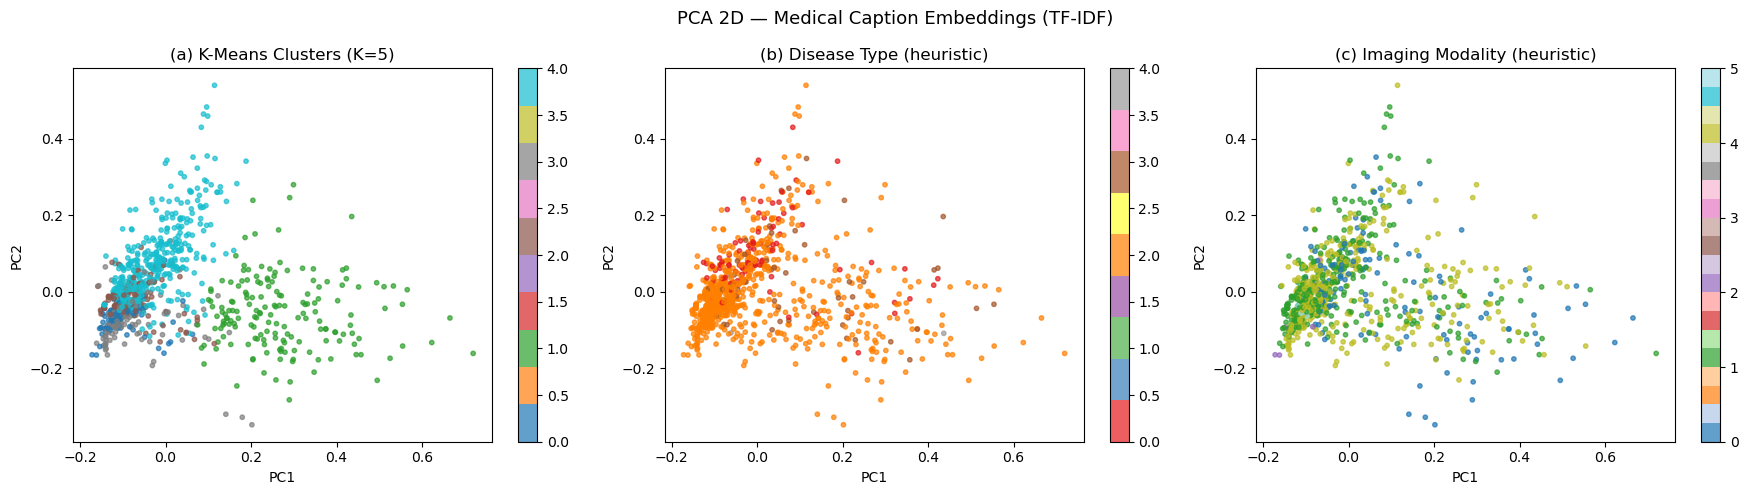

In [42]:
# ----------------------------------------------------------------
# Visualise TF-IDF caption embeddings in 2D via PCA.
# We colour by:
#   (a) K-Means semantic clusters
#   (b) Detected disease type keyword
#   (c) Detected imaging modality keyword
# ----------------------------------------------------------------

# PCA on TDM (sparse → dense)
pca_med = PCA(n_components=2, random_state=42)
X_med_2d = pca_med.fit_transform(TDM.toarray())

# (a) K-Means clusters on TDM
km_med = KMeans(n_clusters=5, random_state=42, n_init='auto')
km_labels = km_med.fit_predict(TDM.toarray())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot (a): Semantic clusters ---
sc = axes[0].scatter(X_med_2d[:, 0], X_med_2d[:, 1],
                     c=km_labels, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('(a) K-Means Clusters (K=5)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc, ax=axes[0])

# --- Plot (b): Disease type (keyword heuristic) ---
disease_keywords = {
    'aneurysm' : 'aneurysm',
    'embolism' : 'embolism',
    'carcinoma': 'carcinoma',
    'stenosis' : 'stenosis',
    'thrombosis': 'thrombosis',
}

def detect_disease(text):
    text = text.lower()
    for kw, label in disease_keywords.items():
        if kw in text:
            return label
    return 'other'

df_caps['disease'] = df_caps['caption'].apply(detect_disease)
dis_labels = df_caps['disease'].astype('category').cat.codes.values

sc2 = axes[1].scatter(X_med_2d[:, 0], X_med_2d[:, 1],
                      c=dis_labels, cmap='Set1', s=10, alpha=0.7)
axes[1].set_title('(b) Disease Type (heuristic)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1])

# --- Plot (c): Imaging modality ---
modality_keywords = {
    'ct'          : 'CT',
    'mri'         : 'MRI',
    'xray'        : 'X-ray',
    'ultrasound'  : 'Ultrasound',
    'angiograph'  : 'Angiography',
    'endoscop'    : 'Endoscopy',
}

def detect_modality(text):
    text = text.lower()
    for kw, label in modality_keywords.items():
        if kw in text:
            return label
    return 'Other'

df_caps['modality'] = df_caps['caption'].apply(detect_modality)
mod_labels = df_caps['modality'].astype('category').cat.codes.values

sc3 = axes[2].scatter(X_med_2d[:, 0], X_med_2d[:, 1],
                      c=mod_labels, cmap='tab20', s=10, alpha=0.7)
axes[2].set_title('(c) Imaging Modality (heuristic)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
plt.colorbar(sc3, ax=axes[2])

plt.suptitle('PCA 2D — Medical Caption Embeddings (TF-IDF)', fontsize=13)
plt.tight_layout()
plt.show()

In [43]:
# ----------------------------------------------------------------
# Open a terminal and type:  streamlit run app.py
# ----------------------------------------------------------------

streamlit_code = '''
# ============================================================
# app.py  –  Medical Image Caption Retrieval Web Interface
# Run with:  streamlit run app.py
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import re, string, os

import nltk
from nltk.corpus import stopwords
for r in ["stopwords", "punkt"]:
    nltk.download(r, quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------------
# Constants
# ------------------------------------------------------------------
CAPTION_FILE = "image_caption.txt"
GLOVE_PATH   = "glove.6B.100d.txt"
EMBED_DIM    = 100
STOP_WORDS   = set(stopwords.words("english"))

# ------------------------------------------------------------------
# Pre-processing
# ------------------------------------------------------------------
def preprocess_medical(text: str) -> str:
    """Lowercase, remove punctuation/numbers, strip stop words."""
    text = text.lower()
    text = re.sub(r"\\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

# ------------------------------------------------------------------
# Cached data loading (runs once, then Streamlit caches the result)
# ------------------------------------------------------------------
@st.cache_data
def load_data():
    df = pd.read_csv(CAPTION_FILE, sep="\\t")
    df.columns = df.columns.str.strip()
    df["clean"] = df["caption"].astype(str).apply(preprocess_medical)
    return df

@st.cache_resource
def build_tfidf(df):
    vec = TfidfVectorizer(max_features=5000)
    tdm = vec.fit_transform(df["clean"])
    return vec, tdm

@st.cache_resource
def load_glove_embeddings(df):
    """Load GloVe and pre-compute caption embeddings (cached)."""
    if not os.path.exists(GLOVE_PATH):
        return None, None
    embeddings = {}
    with open(GLOVE_PATH, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.split()
            embeddings[parts[0]] = np.array(parts[1:], dtype="float32")
    def avg_embed(text):
        vecs = [embeddings[w] for w in text.split() if w in embeddings]
        return np.mean(vecs, axis=0) if vecs else np.zeros(EMBED_DIM)
    cap_embs = np.vstack([avg_embed(t) for t in df["clean"]])
    return embeddings, cap_embs

# ------------------------------------------------------------------
# Retrieval helpers
# ------------------------------------------------------------------
def tfidf_retrieve(query, df, vec, tdm, top_k):
    q_vec = vec.transform([preprocess_medical(query)])
    sims  = cosine_similarity(q_vec, tdm).flatten()
    idx   = np.argsort(sims)[::-1][:top_k]
    out   = df.iloc[idx][["ID", "caption"]].copy()
    out["similarity"] = sims[idx].round(4)
    return out.reset_index(drop=True)

def glove_retrieve(query, df, embed_dict, cap_embs, top_k):
    def avg_embed(text):
        vecs = [embed_dict[w] for w in text.split() if w in embed_dict]
        return np.mean(vecs, axis=0) if vecs else np.zeros(EMBED_DIM)
    q_vec = avg_embed(preprocess_medical(query)).reshape(1, -1)
    sims  = cosine_similarity(q_vec, cap_embs).flatten()
    idx   = np.argsort(sims)[::-1][:top_k]
    out   = df.iloc[idx][["ID", "caption"]].copy()
    out["similarity"] = sims[idx].round(4)
    return out.reset_index(drop=True)

# ------------------------------------------------------------------
# Streamlit UI
# ------------------------------------------------------------------
st.set_page_config(page_title="Medical Caption Retrieval", layout="wide")
st.title("🏥 Medical Image Caption Retrieval")
st.markdown(
    "Search 1,000 medical image captions using **TF-IDF** and/or **GloVe** embeddings."
)

# Load resources
df       = load_data()
vec, tdm = build_tfidf(df)
glove_dict, cap_embs = load_glove_embeddings(df)

# Sidebar controls
st.sidebar.header("Search Settings")
top_k  = st.sidebar.slider("Number of results (K)", min_value=5, max_value=10, value=10)
method = st.sidebar.selectbox("Retrieval method",
                               ["TF-IDF", "GloVe (if available)", "Both"])

# Pre-defined queries + custom input
preset_queries = [
    "angiographic image shows normal coronary artery",
    "CT scan demonstrating pulmonary embolism",
    "MRI showing brain tumor mass",
    "ultrasound of gallbladder with stones",
    "(Custom — type below)",
]
selected = st.selectbox("Choose a preset query or enter your own:", preset_queries)

if selected == "(Custom — type below)":
    query = st.text_input("Enter your query:", "")
else:
    query = selected
    st.text_input("Active query:", value=query, disabled=True)

if st.button("🔍  Search") and query.strip():
    st.markdown(f"**Query:** `{query}`")

    if method in ["TF-IDF", "Both"]:
        st.subheader("TF-IDF Results")
        res_tfidf = tfidf_retrieve(query, df, vec, tdm, top_k)
        st.dataframe(res_tfidf, use_container_width=True)

    if method in ["GloVe (if available)", "Both"]:
        st.subheader("GloVe Embedding Results")
        if glove_dict is None:
            st.warning(f"GloVe file not found at `{GLOVE_PATH}`.  "
                       "Download `glove.6B.100d.txt` and place it in the same folder.")
        else:
            res_glove = glove_retrieve(query, df, glove_dict, cap_embs, top_k)
            st.dataframe(res_glove, use_container_width=True)
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print('app.py written.  Run: streamlit run app.py')

app.py written.  Run: streamlit run app.py
